In [1]:
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib import pyplot as plt
import toml
from pathlib import Path
import os
import glob

## HDUL Class

In [2]:
## multi-HDU class
class AstroImage():

    def __init__(self, fits_file:Path=Path('.fits'), headers:list[dict]=[{}], data:list[np.array]=[np.array([[]])], show_info:bool=False):

        self.fits_file = fits_file
        self.headers = headers
        self.data = data
        self.show_info = show_info

    def read(self):

        self.headers = []
        self.data = []
        
        with fits.open(self.fits_file) as hdul:
            if self.show_info:
                hdul.info()
            for hdu in hdul:
                self.headers.append(hdu.header)
                self.data.append(hdu.data)
            hdul.close()

    def make_header(self, header_dict:dict):
        header = fits.Header()
        for key, value in header_dict.items():
            if key not in {"NAXIS1", "NAXIS2", "PCOUNT", "GCOUNT"}: # astropy automatic keys
                header[key] = value
        return header
    
    def write(self, overwrite=False):

        hdus = [
            fits.PrimaryHDU(
                data=self.data[0],
                header=self.make_header(self.headers[0])
            )
        ]

        hdus.extend(
            fits.ImageHDU(data=data, header=self.make_header(header))
            for data, header in zip(self.data[1:], self.headers[1:])
        )

        fits.HDUList(hdus).writeto(self.fits_file, overwrite=overwrite)

    def concatenate(self, ims:list):
        
        '''
        Creates one multi-HDU AstroImage from a list of single-HDU AstroImages.
        '''

        self.data = [im.data[0] for im in ims]
        self.headers = [im.headers[0] for im in ims]

Ways to initialize an `AstroImage`:
1. Enter a filename and call `read()`.
2. Enter data and headers. (Then, set a filename and call `write()`.)
3. Populate data and header information by calling `concatenate()` with a list of `AstroImage`s

## Generate Observing Log

In [3]:
def sort_frames(frames:list[AstroImage], filenames:list[Path], lampoff_threshold:float=100.0, arcsec_threshold:float=100.0, filter_names:any=None):

    flat_el = 45.0 # degrees, elevation of the flat field frames

    sci = []
    flats = []
    flats_sky = []
    flats_lampon = []
    flats_lampoff = []
    darks = []

    for i, frame in enumerate[AstroImage](frames):

        if filter_names != None:
            if (filter_names in frame.headers[0]["OBJECT"]):
                print(f'[Info]: SKIPPED FRAME {filenames[i].name} DUE TO FILTER NAME(S) "' + filter_names + '"')
                continue

        p1 = SkyCoord(0, flat_el, unit=u.deg)
        p2 = SkyCoord(0, frame.headers[0]["EL"], unit=u.deg)
        altaz_distance = p2.separation(p1).degree * 3600

        if (altaz_distance <  arcsec_threshold) and (frame.headers[0]["WCDMSTAT"].lower() == "open" or frame.headers[0]["WCDMSTAT"].lower() == "idle") and (frame.headers[0]["WCDTSTAT"].lower() == "open" or frame.headers[0]["WCDTSTAT"].lower() == "idle"):

            if np.median(frame.data) < lampoff_threshold:
                print(f'[Info]: LAMPOFF FRAME filename={filenames[i].name} object={frame.headers[0]["OBJECT"]} targname={frame.headers[0]["TARGNAME"]} altaz_distance={altaz_distance}')
                flats_lampoff.append(str(filenames[i]))
            else:
                print(f'[Info]: LAMPON FRAME filename={filenames[i].name} object={frame.headers[0]["OBJECT"]} targname={frame.headers[0]["TARGNAME"]} altaz_distance={altaz_distance}')
                flats_lampon.append(str(filenames[i]))

        elif "sky" in frame.headers[0]["OBJECT"].lower() or "twi" in frame.headers[0]["OBJECT"].lower():

            print(f'[Info]: SKY FLAT FRAME filename={filenames[i].name} object={frame.headers[0]["OBJECT"]} targname={frame.headers[0]["TARGNAME"]}')
            flats_sky.append(str(filenames[i]))

        elif frame.headers[0]["SHRNAME"] == "closed":

            print(f'[Info]: DARK FRAME filename={filenames[i].name} object={frame.headers[0]["OBJECT"]} targname={frame.headers[0]["TARGNAME"]}')
            darks.append(str(filenames[i]))
        
        else:
            print(f'[Info]: SCI FRAME filename={filenames[i].name} object={frame.headers[0]["OBJECT"]} targname={frame.headers[0]["TARGNAME"]}')
            sci.append(str(filenames[i]))


    if flats_lampoff == []:
        print('[Info]: No lamp-off flats found, assuming regular flats...')
        flats = flats_lampon
        flats_lampon = []

    print(f'[Info]: Found {len(sci)} science frames')
    print(f'[Info]: Found {len(flats)} regular flats')
    print(f'[Info]: Found {len(flats_lampon)} lamp-on flats')
    print(f'[Info]: Found {len(flats_lampoff)} lamp-off flats')
    print(f'[Info]: Found {len(darks)} dark frames')

    return sci, flats, flats_sky, flats_lampon, flats_lampoff, darks

In [4]:
def make_obslog(data_folder:Path, date:str, obslog_filepath:Path, sci:list[str], flats:list[str], flats_sky:list[str], flats_lampon:list[str], flats_lampoff:list[str], darks:list[str]):

    obslog = {
        "data_folder":str(data_folder),
        "date":date,
        "raw":{
            "sci":sci,
            "flats":flats,
            "flats_sky":flats_sky,
            "flats_lampon":flats_lampon,
            "flats_lampoff":flats_lampoff,
            "darks":darks
        }
    }

    toml_string = toml.dumps(obslog)
    output_file = Path(obslog_filepath)
    
    with open(output_file, "w") as toml_file:
        toml.dump(obslog, toml_file)
        toml_file.close()

In [5]:
def generate_obslogs_generic():

    date = '2025-12-07'
    observation_folder = Path.cwd().parent / Path(date)
    data_folder = observation_folder / Path('raw')
    output_folder = observation_folder / Path('obslogs')

    Path(output_folder).mkdir(exist_ok=True)

    print(f'[Info]: Using data directory {data_folder}')

    frames = []
    filenames = []

    for file in data_folder.glob('*.fits'):
        frame = AstroImage(fits_file=file)
        frame.read()
        frames.append(frame)
        filenames.append(Path(observation_folder) / Path('raw') / Path(file))

    sorted_frames = sort_frames(frames, filenames, filter_names="pol_cal")
    make_obslog(output_folder, date, Path(output_folder) / Path(f'{date}_obslog.toml'), *sorted_frames)

In [90]:
generate_obslogs_generic()

[Info]: Using data directory /home/shared/exoserver/NIRC2_Pol/ashish_reduction/2025-12-07/raw
[Info]: DARK FRAME filename=n0001.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0002.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0003.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0004.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0005.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0006.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0007.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0008.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0009.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0010.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0011.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0012.fits object=dark targname=unknown
[Info]: DARK FRAME filename=n0013.fits object=dark targname=unknown
[Info]: DARK FRAME fil

## Bad Pixel Replacer

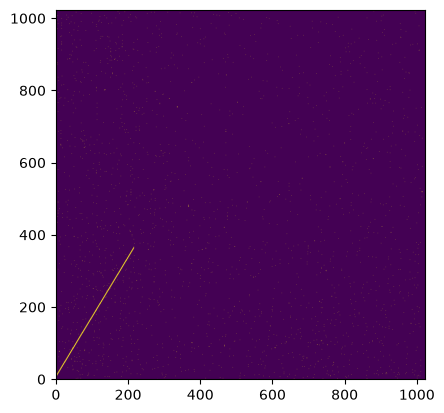

In [6]:
mask_file = Path.cwd() / Path('masks') / Path('bad_pixel_mask_20230101.fits')
NIRC2_bad_pixel_mask = AstroImage(fits_file=mask_file) # from AstroImages or FITSIO
NIRC2_bad_pixel_mask.read()
plt.imshow(NIRC2_bad_pixel_mask.data[0], origin='lower')

In [7]:
def load_frames(obslog_dict:dict, key:str, rejects:list) -> list[AstroImage]:

    frames = []

    if key not in obslog_dict["raw"].keys():
        return frames

    for file in obslog_dict["raw"][key]:
        if os.path.basename(file) in rejects:
            continue

        frame = AstroImage(fits_file=Path(file))
        frame.read()
        frames.append(frame)

    return frames

In [8]:
def median_replace(data:np.array, mask:np.ndarray, median_size:int, fail_val:float=0.0):
    '''
    Replaces bad pixels with the median of a box around them. True = Bad Pixel
    '''

    new_data = data
    bad_indicies = np.array(np.where(mask)).T
    half_size = np.floor(median_size / 2)

    h, w = data.shape
    h_i = h - 1
    w_i = w - 1
    
    for index in bad_indicies:

        i, j = index
        min_i = int(max(0, i-half_size))
        max_i = int(min(i+half_size, h_i) + 1)
        min_j = int(max(0, j-half_size))
        max_j = int(min(j+half_size, w_i) + 1)


        window_d = data[min_i:max_i, min_j:max_j]
        window_m = mask[min_i:max_i, min_j:max_j]
        sample_pixels = window_d[~window_m] # sort bad pixel to the front and remove it
        # if no good pixels, use fail_val
        if np.any(~window_m):
            new_data[i,j] = np.median(sample_pixels)
        else:
            new_data[i,j] = fail_val

    return new_data

In [9]:
def crop(img:np.array, crop_size:tuple, center:tuple=None):
    """
    Crop a 2D NumPy array.

    Parameters
    ----------
    img : np.ndarray
        Input image array.
    crop_size : tuple[int, int]
        Desired crop size as (crop_h, crop_w).
    center : tuple[float, float] or None
        Center position as (y, x). If None, use image center.

    Returns
    -------
    cropped_img : np.ndarray
    offset_y : int
    offset_x : int
    """

    h, w = img.shape
    crop_h, crop_w = crop_size

    if h == crop_h and w == crop_w:
        print("[Info]: No cropping needed, input size equals output size!")
        return img, 0.0, 0.0

    # parity checks
    if not ((h % 2 == 0 and crop_h % 2 == 0) or
            (h % 2 == 1 and crop_h % 2 == 1)):
        print(
            "[Debug]: Input and output height are not both even or both odd, "
            "final image will offset"
        )

    if not ((w % 2 == 0 and crop_w % 2 == 0) or
            (w % 2 == 1 and crop_w % 2 == 1)):
        print(
            "[Debug]: Input and output width are not both even or both odd, "
            "final image will offset"
        )

    if center is None:
        image_center_y = (h / 2) + 1
        image_center_x = (w / 2) + 1
    else:
        image_center_y, image_center_x = center

    # Julia is 1-indexed, Python is 0-indexed
    start_row = round(image_center_y - crop_h / 2)
    end_row = round(start_row + crop_h - 1)

    start_col = round(image_center_x - crop_w / 2)
    end_col = round(start_col + crop_w - 1)

    # convert to Python indexing
    start_row = int(start_row - 1)
    end_row = int(end_row)

    start_col = int(start_col - 1)
    end_col = int(end_col)

    if (
        start_row < 0 or
        start_col < 0 or
        end_row > h or
        end_col > w
    ):
        raise ValueError(
            f"Crop would go out of bounds: "
            f"img size {img.shape}, "
            f"({image_center_y}, {image_center_x}), "
            f"crop_size {crop_size}"
        )

    # offsets relative to original image
    offset_x = start_col
    offset_y = start_row

    cropped = img[start_row:end_row, start_col:end_col]

    return cropped, offset_y, offset_x

In [10]:
def make_sigma_clip_mask(image_data:np.array, n_sigma:float=9.0):

    if image_data.shape == (0,):
        return np.array([])

    mean_val = np.median(image_data)
    std_dev = np.std(image_data)
    threshold = mean_val + (n_sigma * std_dev)
    mask = image_data > threshold

    return mask

In [11]:
def match_keys(frames:list[AstroImage], keylist:list[str]):
    matched_dict = {}
    for frame in frames:
        # create a new key based on the values of the keys in the keylist
        key = tuple[any, ...](frame.headers[0][k] for k in keylist)

        if key in matched_dict.keys():
            matched_dict[key] += [frame.data[0]]
        else:
            matched_dict[key] = [frame.data[0]]

    return matched_dict

In [12]:
def all_header_keywords_match(ha:AstroImage, hb:AstroImage, kws:list[str]):
    for kw in kws:
        if ha.headers[0][kw] != hb.headers[0][kw]:
            return False
    return True

In [13]:
def find_matching_master(frame:AstroImage, masters:dict[tuple, AstroImage], keylist:list[str]):

    if not masters:
        return None, None

    matches = [all_header_keywords_match(frame, m, keylist) for m in masters.values()]

    if np.any(matches):
        ind = np.argmax(matches)
        matched = list[AstroImage](masters.values())[ind]
    else:
        return None, None

    return ind, matched

In [14]:
def make_masters(frames:list[AstroImage], keylist:list[str], n_sigma:np.float64=6.0, median_size:np.int64=7, method:callable=np.median, min_frames:np.int64=3):

    frame_dict = match_keys(frames, keylist)

    bad_keys = []
    print(f'[Info]: Using keylist {keylist}')

    for key in frame_dict.keys():
        if len(frame_dict[key]) < min_frames:
            print(f'[Warning]: Not enough frames for keys list {key}. {len(frame_dict[key])} frame(s) found, {min_frames} needed. skipping...')
            bad_keys.append(key)
        else:
            print(f'[Info]: Making master for keys list -> {key}, frame count -> {(len(frame_dict[key]))}')
    
    for bad_key in bad_keys:
        del(frame_dict[bad_key])

    master_frames = {}
    master_frames_masks = {}

    for key in frame_dict.keys():

        # applies method (mean or median) to frame list
        stack = np.array(frame_dict[key])
        method_stack = method(stack, axis=0)
        mf = AstroImage(data=[method_stack])

        # take each frame, make a sigma clip mask, and then combine them or-wise
        masks = [make_sigma_clip_mask(frame, n_sigma) for frame in frame_dict[key]]
        sigma_clip_mask = np.any(masks, axis=0)

        # crop the original bad pixel mask to the size of the median frame
        bad_pixel_mask = NIRC2_bad_pixel_mask.data[0]
        if bad_pixel_mask.shape != method_stack.shape:
            print(f'[Info]: Cropping NIRC2 bad pixel mask to {method_stack.shape} for key {key}')
            bad_pixel_mask, _, _ = crop(bad_pixel_mask, method_stack.data.shape)

        # combine masks
        mask = np.bool(bad_pixel_mask | sigma_clip_mask)
        m = AstroImage(data=[mask])

        # make the median frame to do pixel replacement
        # not super efficient, but it works

        median_mf = median_replace(method_stack, mask, median_size)

        ## finally, assign the median values to the masked pixels
        mf.data[0][mask] = median_mf[mask]

        # repopulate the header with the key values so we can find the keys later
        for i, k in enumerate(keylist):
            mf.headers[0][k] = key[i]

        mf.headers[0]["FILENAME"] = frames[0].headers[0]["FILENAME"] # copy the first file name to the master
        mf.headers[0]["NFRAMES"] = len(frame_dict[key])
        mf.headers[0]["NSIGMASK"] = n_sigma
        mf.headers[0]["MEDSIZE"] = median_size
        mf.headers[0]["NPIXMASK"] = np.sum(np.int8(mask))
        mf.headers[0]["MAMEDIAN"] = np.median(method_stack[~mask]) # weird notation I just learned today
        mf.headers[0]["MAMEAN"] = np.mean(method_stack[~mask])
        mf.headers[0]["MASTD"] = np.std(method_stack[~mask])
        mf.headers[0]["SAMPMODE"] = frames[0].headers[0]["SAMPMODE"]
        mf.headers[0]["READS"] = frames[0].headers[0]["READS"]

        master_frames[key] = mf
        master_frames_masks[key] = m

    return master_frames, master_frames_masks

In [15]:
def find_closest_dark(frame:AstroImage, master_darks:dict[tuple, AstroImage], ranked_darks_keylist=[["NAXIS1", "NAXIS2", "ITIME", "COADDS", "SAMPMODE", "READS"], ["NAXIS1", "NAXIS2", "ITIME", "COADDS", "SAMPMODE"], ["NAXIS1", "NAXIS2", "ITIME", "COADDS"], ["NAXIS1", "NAXIS2", "ITIME"], ["ITIME"]]):
    """
    Guarantees finding a dark frame that matches at least the ITIME. Frame should be cropped as well.

    # Arguments
    - `frame`: The frame for which we want to find a matching dark.
    - `master_darks`: A dictionary of master dark frames.
    - `ranked_darks_keylist`: A list of keylists in order of preference for matching dark frames. Each keylist is a list of header keywords that should match. At minimum we want to match the ITIME.
    """

    if not master_darks:
        return None, None

    
    for i, keylist in enumerate[list](ranked_darks_keylist):

        ind, matched_dark = find_matching_master(frame, master_darks, keylist)
        if matched_dark != None:

            # for the 2nd and 3rd case, rescale by coadds
            if (i == 3) or (i == 4):
                print(f'[Warning]: Rescaling dark frame by COADDS {matched_dark.headers[0]["COADDS"]} -> {frame.headers[0]["COADDS"]}')
                matched_dark.data[0] = matched_dark.data[0] / matched_dark["COADDS"] * frame.headers[0]["COADDS"]

            if i == 4:
                if matched_dark.data[0].shape != frame.data[0].shape:
                    if np.all(np.array(matched_dark.data[0].shape) > np.array(frame.data[0].shape)):
                        cropped_dark = matched_dark[:frame.data[0].shape[0], :frame.data[0].shape[1]]
                        matched_dark.data[0] = cropped_dark
                    else:
                        print(f'[Warning]: Dark frame is smaller than the target frame, not cropping: {frame.headers[0]["FILENAME"]}')
                        return None
            break

    if matched_dark == None:
        print(f'[Warning]: No matching dark found for FILENAME={frame.data[0].header["FILENAME"]}, FILTER={frame.data[0].header["FILTER"]}, ITIME={frame.data[0].header["ITIME"]}, COADDS={frame.data[0].header["COADDS"]}')

    return ind, matched_dark

In [16]:
def make_flats(flat_frames:list[AstroImage], master_darks:dict[tuple, AstroImage], flats_keylist:list[str], flattype:str):
    
    if len(flat_frames) != 0:

        master_flats, master_flats_masks = make_masters(flat_frames, flats_keylist, method=np.median)

        for key in master_flats.keys():
            
            ind, matched_dark = find_closest_dark(master_flats[key], master_darks)

            if matched_dark != None:
                print('[Info]: Subtracting dark from master flat')
                master_flats[key].data[0] -= matched_dark.data[0]
                master_flats[key].headers[0]["FLATTYPE"] = flattype
            else:
                print('[Warning]: No matching dark found for master flat')
                master_flats[key].headers[0]["FLATTYPE"] = flattype + "NODARK"

            master_flats[key].data[0] /= master_flats[key].headers[0]["MAMEDIAN"]

    else:
        print('[Warning]: No regular flats found, skipping...')
        master_flats = {}
        master_flats_masks = {}

    return master_flats, master_flats_masks

In [18]:
def make_lamp_flats(lampon_frames:list[AstroImage], lampoff_frames:list[AstroImage], master_darks:dict[tuple, AstroImage], flats_keylist:list[str]):

    if lampon_frames:
        master_lampon, master_lampon_masks = make_masters(lampon_frames, flats_keylist, method=np.median)
    else:
        print('[Warning]: No lampon frames found, skipping...')
        master_lampon = {}
        master_lampon_masks = {}

    if lampoff_frames:
        master_lampoff, master_lampoff_masks = make_masters(lampoff_frames, flats_keylist, method=np.median)
    else:
        print('[Warning]: No lampoff frames found, skipping...')
        master_lampoff = {}
        master_lampoff_masks = {}

    master_flat_lamp = {}
    master_flat_lamp_masks = {}

    for key in master_lampon.keys():
        sub_frame = np.zeros_like(master_lampon[key].data[0])

        master_flat_lamp[key] = master_lampon[key]
        
        # check if there is a corresponding lamp-off flat
        if key in master_lampoff.keys():
            sub_frame = master_lampoff[key].data[0]
            master_flat_lamp_masks[key] = AstroImage()
            master_flat_lamp[key].headers[0]["FLATTYPE"] = "LAMP"
            master_flat_lamp_masks[key].data[0] = master_lampon_masks[key].data[0] | master_lampoff_masks[key].data[0] # combine masks

        # if there is no corresponding lamp-off flat, use the dark frame
        else:

            matched_dark = find_closest_dark(master_lampon[key], master_darks)
            if matched_dark == None:
                print('[Warning]: No matching dark found for lamp-on flat')
                master_flat_lamp[key].headers[0]["FLATTYPE"] = "LAMP+NODARK"
            else:
                print('[Warning]: Using dark frame to subtract from lamp-on flat')
                sub_frame = matched_dark[1].data[0]
                master_flat_lamp[key].headers[0]["FLATTYPE"] = "LAMP+DARK"

            master_flat_lamp_masks[key] = AstroImage(data=[master_lampon_masks[key].data[0]]) # just use lampon mask if no lampoff frame is found

        # subtract the lamp-off flat or dark frame from the lamp-on flat
        master_flat_lamp[key].data[0] -= sub_frame

        # now get the median value
        # this should be bad pixel corrected already
        medval = np.median(master_flat_lamp[key].data[0])

        master_flat_lamp[key].data[0] /= medval

    return master_flat_lamp, master_flat_lamp_masks

In [19]:
class Obslog():

    def __init__(self, observations_folder:Path, obslog_file:Path): 

        self.obslog_file = obslog_file

        with open(obslog_file, 'r') as file:
            self.obslog_dict = toml.load(file)
            file.close()

        self.date = self.obslog_dict["date"]
        self.data_folder = self.obslog_dict["data_folder"]

        self.master_darks = {}
        self.master_flats = []
        self.master_skies = []
        self.masks = []
        self.sci = []

        self.sequences = {}
        self.rejects = []

        self.is_loaded = False

        self.raw_folder = observations_folder / Path('raw')
        self.reduced_folder = observations_folder / Path('reduced')
        self.plots_folder = observations_folder / Path('plots')
        self.sequences_folder = observations_folder / Path('sequences')

        self.reduced_file = observations_folder / Path(f'{self.date}_reduced.toml')
        self.rejects_file = observations_folder/ Path(f'{self.date}_rejects.toml')
        self.sequences_file = observations_folder / Path(f'{self.date}_sequences.toml')
        self.table_file = observations_folder / Path(f'{self.date}_reduced_frames_table.txt')

        self.darks_file = observations_folder / Path('darks.fits')
        self.flats_file = observations_folder / Path('flats.fits')
        self.skies_file = observations_folder / Path('skies.fits')
        self.masks_file = observations_folder / Path('master_mask.fits')

    def load_files(self, rejects_file=Path('.toml')):

        if rejects_file.exists():
            print(f'[Info]: Rejects file found: {rejects_file}')

            with open(rejects_file, "r") as file:
                self.rejects = toml.load(file)["rejects"]
                file.close()
        else:
            print(f'[Info]: No rejects file found.')

        self.sci = load_frames(self.obslog_dict, "sci", rejects=self.rejects)

        protected_keys = ["data_folder"] # obslog_path
        if "sequences" in str(self.obslog_dict["data_folder"]): #obslog_path
            for key in self.obslog_dict.keys():
                if not (key in protected_keys):
                    self.sequences[key] = load_frames(self.obslog_dict, key, rejects=self.rejects)

        self.is_loaded = True

    def make_master_darks(self, darks_keylist:list[str]=["NAXIS1", "NAXIS2", "ITIME", "COADDS"]):

        darks_frames = load_frames(self.obslog_dict, "darks", rejects=self.rejects)
        self.master_darks, self.master_darks_masks = make_masters(darks_frames, darks_keylist)

        print(f'[Info]: Writing master darks to {self.darks_file}')
        darks_image = AstroImage(fits_file=self.darks_file)

        darks_image.concatenate(self.master_darks.values())
        darks_image.write(overwrite=True)

    def make_master_flats(self, flats_keylist=["NAXIS1", "NAXIS2", "ITIME", "COADDS", "FILTER"], flattype="REGULAR"):

        ## regular flats
        flat_frames = load_frames(self.obslog_dict, "flats", rejects=self.rejects)
        master_flats, master_flats_masks = make_flats(flat_frames, self.master_darks, flats_keylist, flattype)

        ## sky flats
        sky_frames = load_frames(self.obslog_dict, "flat_sky", rejects=self.rejects)
        master_flats_sky, master_flats_sky_masks = make_flats(sky_frames, self.master_darks, flats_keylist, "SKY")

        ## lamp flats
        lampon_frames = load_frames(self.obslog_dict, "flats_lampon", rejects=self.rejects)
        lampoff_frames = load_frames(self.obslog_dict, "flats_lampoff", rejects=self.rejects)
        master_flat_lamp, master_flat_lamp_masks = make_lamp_flats(lampon_frames, lampoff_frames, self.master_darks, flats_keylist)

        # ranking so that the best type of flat for a given key is always first on the list
        # when searching through flats, just pick the first one that matches
        
        merged_flats = master_flats | master_flats_sky | master_flat_lamp # merge dictionaries
        list_flats = list(merged_flats.values()) # convert Dict to Vector
        ranking = ["SKY", "LAMP", "LAMP+DARK", "REGULAR", "SKY+NODARK", "LAMP+NODARK", "REGULAR+NODARK"]
        rank_dict = {r: i for i, r in enumerate(ranking, start=1)}
        list_flats.sort(key=lambda frame: rank_dict.get(
            frame.headers[0]["FLATTYPE"],
            len(ranking) + 1
        ))

        self.master_flats = list_flats
        self.master_flats_masks = master_flats_masks | master_flats_sky_masks | master_flat_lamp_masks

        print(f'[Info]: Writing master flats to {self.flats_file}')
        flats_image = AstroImage(fits_file=self.flats_file)
        flats_image.concatenate(self.master_flats)
        flats_image.write(overwrite=True)

    def make_master_masks(self):

        # master_masks = make_master_masks(self.master_darks_masks, self.master_flats_masks)

                # sort masks by size
        mask_stack = {}
        a = [img.data[0] for img in self.master_darks_masks.values()]
        b = [img.data[0] for img in self.master_flats_masks.values()]
        for mask in a + b:
            key = mask.shape

            if key not in mask_stack:
                mask_stack[key] = []

            mask_stack[key].append(mask)

        # Combine masks by size
        master_masks = {}

        for key, masks in mask_stack.items():
            # Logical OR of all masks with this shape
            mm = np.logical_or.reduce(masks)

            # Convert boolean mask to UInt8 for FITS
            mm = mm.astype(np.uint8)

            master_masks[key] = mm


        self.masks = [AstroImage(data=[mask]) for mask in list(master_masks.values())]
        print(f'[Info]: Writing master masks to {self.masks_file}')
        masks_image = AstroImage(fits_file=self.masks_file)
        masks_image.concatenate(self.masks)
        masks_image.write(overwrite=True)

In [104]:
date = '2025-12-07'
observation_folder = Path.cwd().parent / Path(date)
obslog_folder = observation_folder / Path('obslogs')

for obslog_filename in obslog_folder.glob('*_obslog.toml'):

    obslog_file = Path(obslog_filename)

    print(f'[Info]: Loading obslog from {obslog_file}')
    
    obslog = Obslog(observation_folder, obslog_file)
    obslog.load_files()

    ## create darks file
    print('[Info]: Making darks...')
    obslog.make_master_darks()

    ## create flats file (must be run after darks have been created)
    print('[Info]: Making flats...')
    obslog.make_master_flats()

    # create mask file
    print('[Info]: Making master masks...')
    obslog.make_master_masks()

[Info]: Loading obslog from /home/shared/exoserver/NIRC2_Pol/ashish_reduction/2025-12-07/obslogs/2025-12-07_obslog.toml
[Info]: No rejects file found.
[Info]: Making darks...
[Info]: Using keylist ['NAXIS1', 'NAXIS2', 'ITIME', 'COADDS']
[Info]: Making master for keys list -> (1024, 1024, 0.17, 10), frame count -> 10
[Info]: Making master for keys list -> (1024, 1024, 0.17, 1), frame count -> 10
[Info]: Making master for keys list -> (1024, 1024, 0.17, 20), frame count -> 10
[Info]: Making master for keys list -> (1024, 1024, 0.17, 30), frame count -> 10
[Info]: Making master for keys list -> (1024, 1024, 0.2, 50), frame count -> 10
[Info]: Making master for keys list -> (1024, 1024, 0.3, 30), frame count -> 10
[Info]: Making master for keys list -> (1024, 1024, 0.34, 30), frame count -> 20
[Info]: Making master for keys list -> (1024, 1024, 0.4, 30), frame count -> 20
[Info]: Making master for keys list -> (1024, 1024, 0.5, 30), frame count -> 20
[Info]: Making master for keys list -> 

In [ ]:
def find_closest_flat(frame:AstroImage, master_flats:dict[tuple, AstroImage], flats_keylist:list[str]=["FILTER"]):

    exceptions = {"NB2.108": ("K + clear", "Ks + clear", "Kp + clear")}

    ind = None
    matched_flat = None

    # Handle special filter exceptions
    for key, alternate_flats in exceptions.items():
        if key in frame.headers[0]["FILTER"]:
            for alt in alternate_flats:
                matches = [alt in m.headers[0]["FILTER"] for m in master_flats.values()]

                if any(matches):
                    ind = matches.index(True)
                    matched_flat = master_flats[ind]

                    print(f'WARNING: Using {matched_flat.headers[0]["FILTER"]} flat for {key} frames!')

    # If no exception matched, find a normal matching flat
    if matched_flat is None:
        ind, matched_flat = find_matching_master(frame, master_flats, flats_keylist)

    # Make sure the flat has the same dimensions as the target frame
    if matched_flat is not None:
        if matched_flat.data[0].shape != frame.data[0].shape:

            if np.all(np.array(matched_flat.data[0].shape) > np.array(frame.data[0].shape)):
                cropped_flat, _, _ = crop(matched_flat.data[0], frame.data[0].shape)

                matched_flat = AstroImage(data=[cropped_flat], headers=matched_flat.headers)

            else:
                print(f'WARNING: Flat frame is smaller than the target frame, not cropping: {frame.headers[0]["FILENAME"]}')
                return None, None

    else:
        print(f'WARNING: No matching flat found for {frame.headers[0]["FILENAME"]}, {frame.headers[0]["FILTER"]}')

    return ind, matched_flat

In [26]:
def reduce_frame(frame:AstroImage, master_flats:dict[tuple, AstroImage], master_darks:dict[tuple, AstroImage], masks:dict[tuple, AstroImage], median_size:int=6, gain:float=1.0):

    reduced = frame

    ind_flat, matched_flat = find_closest_flat(reduced, master_flats)
    ind_dark, matched_dark = find_closest_dark(reduced, master_darks)

    if matched_dark == None:
        print(f'[Warning]: No matching dark found for file {reduced.headers[0]["FILENAME"]} ITIME {reduced.headers[0]["ITIME"]} COADDS {reduced.headers[0]["COADDS"]}')
        reduced.headers[0]["DARKSUB"] = False
        matched_dark.data[0] = np.zeros_like(reduced.data[0])
    else:
        reduced.headers[0]["DARKSUB"] = True

    if matched_flat == None:
        print(f'[Warning]: No matching flat found for file {reduced.headers[0]["FILENAME"]} FILTER {reduced.headers[0]["FILTER"]}')
        reduced.headers[0]["FLATDIV"] = False
        matched_flat.data[0] = np.ones_like(reduced.data[0])
    else:
        reduced.headers[0]["FLATDIV"] = True

    reduced.data[0] = (reduced.data[0] - matched_dark.data[0]) / matched_flat

    reduced.data[0] /= reduced.headers[0]["COADDS"] # divide by coadds
    reduced.data[0] *= gain

    # start with the bad pixel mask as our mask
    mask = NIRC2_bad_pixel_mask

    if mask.data[0].shape != reduced.data[0].shape:
        mask, _, _ = crop(NIRC2_bad_pixel_mask.data[0], reduced.data[0].shape)

    if reduced.data[0].shape in masks.keys():
        mask = mask | masks[reduced.data[0].shape] # also combine the extra mask if it exists

    nan_mask = np.isnan(reduced.data[0]) | np.isinf(reduced.data[0]) # create a mask for NaN and Inf values
    mask |= nan_mask # combine the bad pixel mask with the NaN/Inf mask

    reduced.data[0] = median_replace(reduced.data[0], mask, median_size)

    reduced_filename = f'reduced_{reduced.headers[0]["FRAMENO"].zfill(4)}).fits'
    reduced.headers[0]["RED-FN"] = reduced_filename

    return reduced

In [28]:
def get_NIRC2_readnoise(sampmode:int):
    if sampmode == 2:
        return 50.0
    elif sampmode == 3:
        return 15.0
    else:
        return 0.0

In [ ]:
# @info "Using $(Threads.nthreads()) threads for reduction"

allowed = ['2025-12-07']

observation_folder = Path.cwd().parent / Path(date)
obslog_folder = observation_folder / Path('obslogs')

for obslog_filename in glob.glob(os.path.join(obslog_folder, '*_obslog.toml')):
    if not any(date in obslog_filename for date in allowed):
        print(f'WARNING: Skipping file: {obslog_filename} (not in allowed dates)')
        continue

    print(f'Loading obslog from {obslog_filename}')
    obslog = Obslog(observation_folder, obslog_filename)

    # p = Progress(length(obslog.sci))
    # update!(p, 0)
    # counter = Threads.Atomic{Int}(0)
    # lock = Threads.SpinLock()

    gain = 8.0 # gain is the same for all dates. 4.0 for pre-2023

    # no LACosmic, probably more trouble than it's worth

    reduced_frames = [AstroImage]*len(obslog.obslog_dict["sci"])

    # Threads.@threads for i in eachindex(obslog.sci)
    for i, file in enumerate[any](obslog.obslog_dict["sci"]):

        frame = AstroImage(fits_file=file)
        frame.read()

        reduced = reduce_frame(frame, obslog.master_flats, obslog.master_darks, obslog.masks, gain=gain)

        readnoise = get_NIRC2_readnoise(reduced["SAMPMODE"])
        reduced["RDNOISE"] = readnoise

        reduced_frames[i] = reduced

    #     Threads.atomic_add!(counter, 1)
    #     Threads.lock(lock)
    #     update!(p, counter[])
    #     Threads.unlock(lock)
    # end

#     @info "Reduced $(length(reduced_frames)) science frames"

#     make_and_clear(obslog.paths.reduced_folder, "reduced_*.fits")

#     reduced_filepaths = String[]
#     for rf in reduced_frames
#         reduced_filepath = joinpath(obslog.paths.reduced_folder, rf["RED-FN"])
#         push!(reduced_filepaths, rf["RED-FN"])
#         @info "Saving reduced frame to $(reduced_filepath)"
#         save(reduced_filepath, rf)
#     end

#     reduced_obslog = OrderedDict{String, Any}("data_folder" => obslog.paths.data_folder,
#                                                 "date" => obslog.date,
#                                                 "reduced" => OrderedDict{String, Any}(
#                                                 "reduced_sci" => reduced_filepaths))

#     write_toml(obslog.paths.reduced_file, reduced_obslog)

# end

# end